In [1]:
import pandas as pd
import numpy as np

In [14]:
df=pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [16]:
df['species']=encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
df=df[df['species']!=0][['sepal_length','petal_length','species']]
df.head()

,sepal_length,petal_length,species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

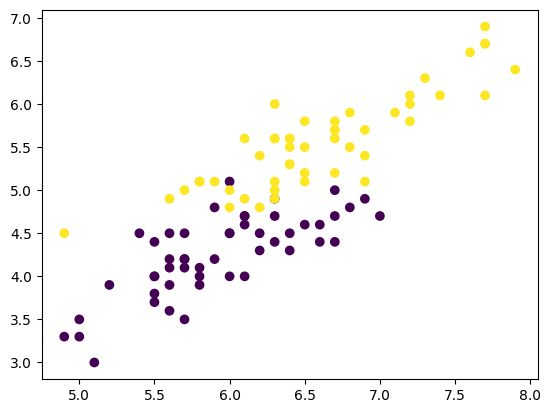

In [20]:
plt.scatter(df['sepal_length'],df['petal_length'],c=df['species'])

In [21]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [23]:
df_train

,sepal_length,petal_length,species
74,6.4,4.3,1
104,6.5,5.8,2
58,6.6,4.6,1
142,5.8,5.1,2
54,6.5,4.6,1
101,5.8,5.1,2
135,7.7,6.1,2
136,6.3,5.6,2
119,6.0,5.0,2
109,7.2,6.1,2


In [24]:
df_test

,sepal_length,petal_length,species
62,6.0,4.0,1
120,6.9,5.7,2
100,6.3,6.0,2
78,6.0,4.5,1
70,5.9,4.8,1


In [25]:
df_val

,sepal_length,petal_length,species
128,6.4,5.6,2
61,5.9,4.2,1
56,6.3,4.7,1
130,7.4,6.1,2
89,5.5,4.0,1


In [26]:
x_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

In [27]:
x_test

array([[6.4, 5.6],
       [5.9, 4.2],
       [6.3, 4.7],
       [7.4, 6.1],
       [5.5, 4. ]])

In [28]:
y_test

array([2, 1, 1, 2, 1])

                Bagging

In [30]:
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_length,petal_length,species
142,5.8,5.1,2
136,6.3,5.6,2
104,6.5,5.8,2
135,7.7,6.1,2
135,7.7,6.1,2
142,5.8,5.1,2
58,6.6,4.6,1
109,7.2,6.1,2


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score 

In [33]:
dt_bag1=DecisionTreeClassifier()

In [35]:
def evaluate(clf,x,y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values,y.values,clf=clf,legend=2)
    y_pred=clf.predict(x_test)
    print(accuracy_score(y_test,y_pred))

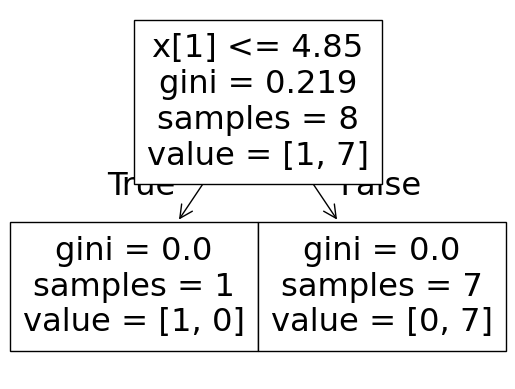

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


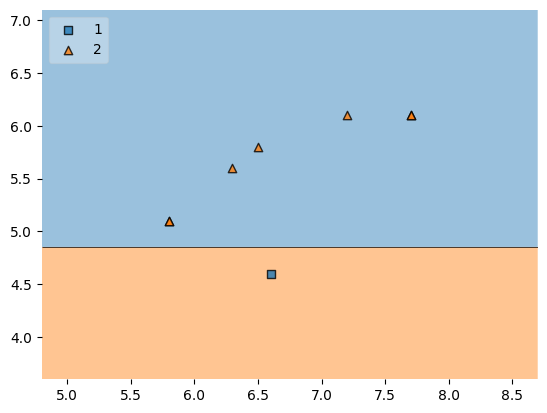

In [36]:
evaluate(dt_bag1,x,y)

In [37]:
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_length,petal_length,species
104,6.5,5.8,2
54,6.5,4.6,1
101,5.8,5.1,2
74,6.4,4.3,1
58,6.6,4.6,1
54,6.5,4.6,1
74,6.4,4.3,1
135,7.7,6.1,2


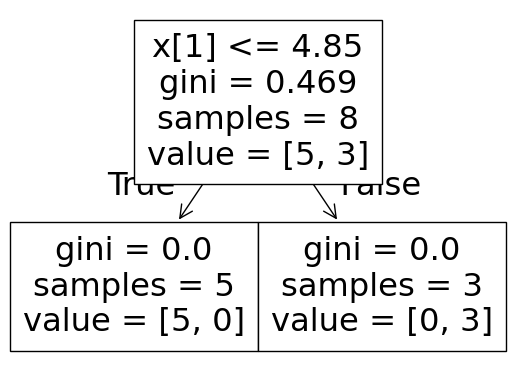

1.0


c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


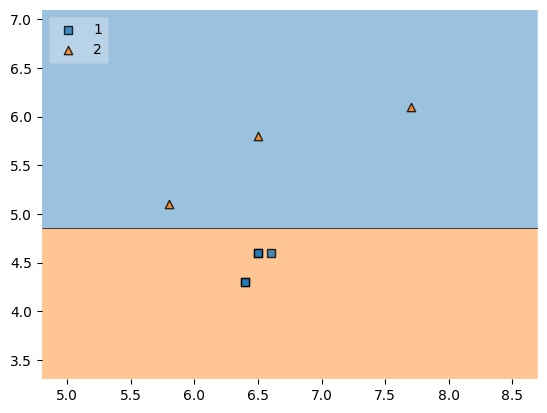

In [38]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

In [39]:
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_length,petal_length,species
74,6.4,4.3,1
74,6.4,4.3,1
104,6.5,5.8,2
58,6.6,4.6,1
135,7.7,6.1,2
101,5.8,5.1,2
109,7.2,6.1,2
74,6.4,4.3,1


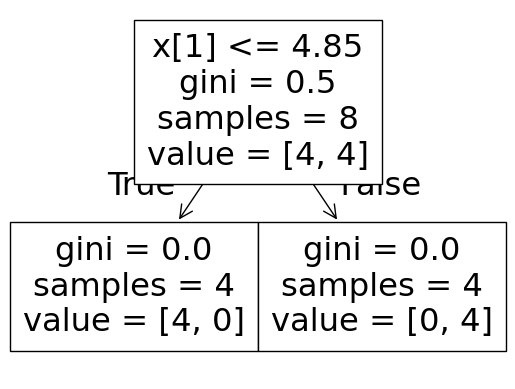

1.0


c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


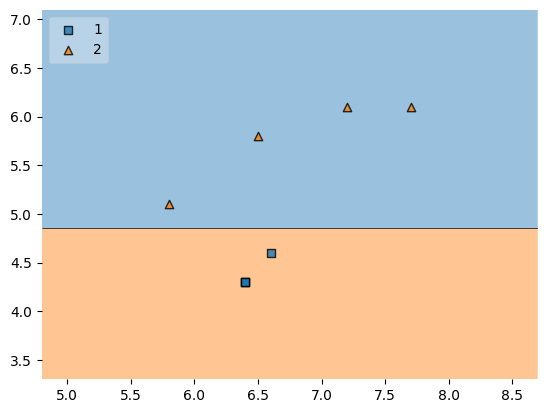

In [40]:
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

            Predict

In [41]:
df_test

,sepal_length,petal_length,species
62,6.0,4.0,1
120,6.9,5.7,2
100,6.3,6.0,2
78,6.0,4.5,1
70,5.9,4.8,1


In [43]:
print("Predictor1:",dt_bag1.predict(np.array([3.2,4.7]).reshape(1,2)))
print("Predictor1:",dt_bag2.predict(np.array([3.2,4.7]).reshape(1,2)))
print("Predictor1:",dt_bag3.predict(np.array([3.2,4.7]).reshape(1,2)))

Predictor1: [1]
Predictor1: [1]
Predictor1: [1]


c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [51]:
print("Predictor1:",dt_bag1.predict(np.array([6.9,5.7]).reshape(1,2)))
print("Predictor2:",dt_bag2.predict(np.array([6.9,5.7]).reshape(1,2)))
print("Predictor3:",dt_bag3.predict(np.array([6.9,5.7]).reshape(1,2)))

Predictor1: [2]
Predictor2: [2]
Predictor3: [2]


c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


                Pasting
--- Row Smapling without replacement

In [52]:
df_train.sample(5)

,sepal_length,petal_length,species
136,6.3,5.6,2
54,6.5,4.6,1
101,5.8,5.1,2
142,5.8,5.1,2
109,7.2,6.1,2


                Random Subspaces
---- column sampling

In [53]:
df1=pd.read_csv("iris.csv")
df1=df1.sample(10)

In [54]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
20,5.4,3.4,1.7,0.2,setosa
10,5.4,3.7,1.5,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
13,4.3,3.0,1.1,0.1,setosa
109,7.2,3.6,6.1,2.5,virginica
31,5.4,3.4,1.5,0.4,setosa
141,6.9,3.1,5.1,2.3,virginica
119,6.0,2.2,5.0,1.5,virginica
24,4.8,3.4,1.9,0.2,setosa


In [59]:
df1.sample(2,replace=True,axis=1)

,petal_length,sepal_length
20,1.7,5.4
10,1.5,5.4
2,1.3,4.7
5,1.7,5.4
13,1.1,4.3
109,6.1,7.2
31,1.5,5.4
141,5.1,6.9
119,5.0,6.0
24,1.9,4.8


                Random Patches
    
--row  sampling+column sampling

In [61]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,petal_width,sepal_width
31,0.4,3.4
141,2.3,3.1
13,0.1,3.0
13,0.1,3.0
141,2.3,3.1
109,2.5,3.6
10,0.2,3.7
5,0.4,3.9
